In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
titanic_data = pd.read_csv('data/train.csv')

In [20]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The correlation map shows the relation bw all the features, with higher the color on scale representing linear proportionality and lower representing inverse proportionality.
For eg, survived is inversely proportionate to PClass or ticket class as lower number ticket class means higher class, hence increased survival

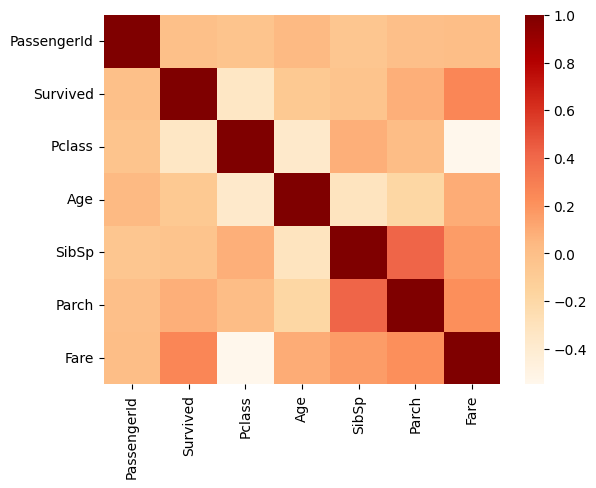

In [ ]:
sns.heatmap(titanic_data.corr(numeric_only=True), cmap = "OrRd")
plt.show()

StratifiedShuffleSplit is used to split the dataset into train/test sets while keeping the proportions of certain categories consistent, in this case  survived, pclass, sex.

n_splits=1 → Perform just one split (train/test).
test_size=0.2 → Keep 20% of the data for testing and 80% for training.



In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2)
for train_indices, test_indices in split.split(titanic_data, titanic_data[['Survived', 'Pclass', 'Sex']]):
    strat_train_set = titanic_data.loc[train_indices]
    strat_test_set = titanic_data.loc[test_indices]

We're plotting the distribution of Survived and Pclass in:
    - strat_train_set (left subplot)
    - strat_test_set (right subplot)

If stratification worked correctly, the relative proportions of categories (0 vs 1 in Survived, and 1st/2nd/3rd in Pclass) should look similar in both train and test sets.

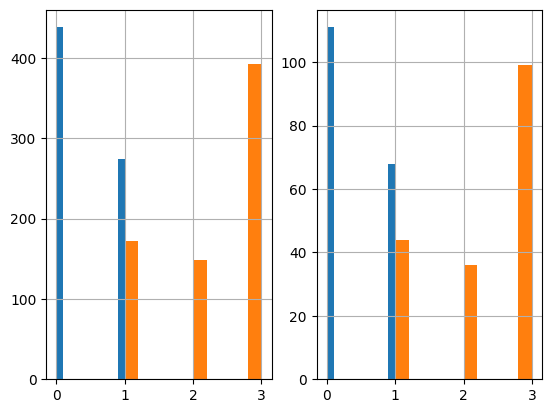

In [31]:
plt.subplot (1, 2,1)
strat_train_set[ 'Survived'].hist()
strat_train_set['Pclass'].hist()

plt.subplot (1, 2, 2)
strat_test_set['Survived' ].hist()
strat_test_set['Pclass'].hist()
plt.show()

In [36]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 747 to 50
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          577 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        167 non-null    object 
 11  Embarked     711 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


In [41]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

class AgeImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y = None):
        return self
    def transform(self, X):
        imputer = SimpleImputer(strategy='mean')
        X['Age'] = imputer.fit_transform(X[['Age']])
        return X

In [44]:
from sklearn.preprocessing import OneHotEncoder

class FeatureEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y = None):
        return self
    def transform(self, X):
        encoder = OneHotEncoder()
        
        matrix = encoder.fit_transform(X[['Embarked']]).toarray()
        
        column_names = ["C", "S", "Q", "N"]
        
        for i in range(len(matrix.T)):
            X[column_names[i]] = matrix.T[i]
            
        matrix = encoder.fit_transform(X[['Sex']]).toarray()
        
        column_names = ["Female", "Male"]
        
        for i in range(len(matrix.T)):
            X[column_names[i]] = matrix.T[i]
        
        return X
        

In [45]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    def fit(self, X, y = None):
        return self
    def transform(self, X):
        return X.drop(["Embarked" , "Name", "Ticket", "Cabin", "Sex", "N"], axis=1, errors='ignore')

In [46]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([("ageimputer", AgeImputer()),
                     ("featureencoder", FeatureEncoder()),
                     ("featuredropper", FeatureDropper())])

In [47]:
strat_train_set = pipeline.fit_transform(strat_train_set)

In [48]:
strat_train_set

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
747,748,1,2,30.000000,0,0,13.0000,0.0,0.0,1.0,1.0,0.0
425,426,0,3,29.750295,0,0,7.2500,0.0,0.0,1.0,0.0,1.0
522,523,0,3,29.750295,0,0,7.2250,1.0,0.0,0.0,0.0,1.0
886,887,0,2,27.000000,0,0,13.0000,0.0,0.0,1.0,0.0,1.0
676,677,0,3,24.500000,0,0,8.0500,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
103,104,0,3,33.000000,0,0,8.6542,0.0,0.0,1.0,0.0,1.0
57,58,0,3,28.500000,0,0,7.2292,1.0,0.0,0.0,0.0,1.0
665,666,0,2,32.000000,2,0,73.5000,0.0,0.0,1.0,0.0,1.0
387,388,1,2,36.000000,0,0,13.0000,0.0,0.0,1.0,1.0,0.0


In [49]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 747 to 50
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
 7   C            712 non-null    float64
 8   S            712 non-null    float64
 9   Q            712 non-null    float64
 10  Female       712 non-null    float64
 11  Male         712 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 72.3 KB
